# 08 · Multivariate Volatility — DCC-GARCH & Dynamic Correlation  (stretch)

## Part 8 — Multivariate Volatility: DCC-GARCH  · *stretch*

Part 4 gave **one** correlation matrix (average pairwise ≈ 0.33). But that single number is a
dangerous average: correlations are **not constant** — they jump in crises, exactly when
diversification is supposed to protect you. Part 7 made each asset's *variance* time-varying;
this notebook makes the whole **correlation matrix** time-varying with **Engle's DCC-GARCH**.

The two-step recipe (Engle, 2002):
1. fit a **univariate GARCH** to each asset → **standardized residuals** (returns with their own
   volatility divided out);
2. let *their* correlation evolve: `Q_t = (1−a−b)·Q̄ + a·z_{t-1}z_{t-1}' + b·Q_{t-1}`, normalised to
   the conditional correlation matrix `R_t`. Estimate `(a, b)` by maximum likelihood.

**Data:** the 12-stock daily panel (2013–2018), with the VIX for context.

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
ROOT = pathlib.Path.cwd()
ROOT = ROOT if (ROOT / "src").exists() else ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src import data, eda
eda.set_style()
pd.set_option("display.width", 120, "display.max_columns", 30)
print("setup ok | numpy", np.__version__, "| pandas", pd.__version__)

from src import mgarch as mg

ret_pct = data.stock_log_returns() * 100        # 12 stocks, daily %, 2013-2018
vix = data.clean_vix()["close"]
PAIRS = [("AAPL", "MSFT"), ("JPM", "BAC"), ("XOM", "CVX")]
print("returns panel:", ret_pct.shape, "|", ret_pct.index.min().date(), "->", ret_pct.index.max().date())


setup ok | numpy 2.1.3 | pandas 2.3.3


returns panel: (1258, 12) | 2013-02-11 -> 2018-02-07


### 1. Why static correlation is dangerous

A single correlation matrix assumes the diversification you measured in calm markets still holds
in a crash. It doesn't: when everything sells off together, pairwise correlations converge toward
1 and a "diversified" book behaves like one big position. We need `R_t`, not `R`.

### 2. Step 1 — devolatize each asset (univariate GARCH → standardized residuals)

Each return carries its own volatility (Part 7). Dividing it out gives **standardized residuals**
`z = ε/σ`, each ~unit variance. What remains *between* assets is the correlation structure DCC will
make dynamic — and it still matches Part 4's static picture.

In [2]:
z = mg.standardized_residuals(ret_pct, dist="t")
off = ~np.eye(z.shape[1], dtype=bool)
print("standardized residuals:", z.shape)
print("avg pairwise corr:  raw returns = %.3f   |   standardized resid = %.3f  (same structure)"
      % (ret_pct.corr().values[off].mean(), z.corr().values[off].mean()))

standardized residuals: (1258, 12)
avg pairwise corr:  raw returns = 0.331   |   standardized resid = 0.307  (same structure)


### 3–4. Step 2 — DCC(1,1): let the correlation move

DCC adds just **two** parameters: `a` = how strongly today's shock pushes correlations, `b` = how
much yesterday's correlation persists. `a + b < 1` keeps it mean-reverting toward the long-run
matrix `Q̄`. We estimate them by maximising the DCC log-likelihood, then replay to recover the
conditional-correlation path. (We also compute the simpler **EWMA / RiskMetrics** correlation as a
baseline.)

In [3]:
out = mg.dcc(z, pairs=PAIRS)
print("DCC(1,1):  a = %.4f   b = %.4f   persistence a+b = %.3f  (<1, mean-reverting)"
      % (out["a"], out["b"], out["persistence"]))
print("unconditional avg correlation Q-bar = %.3f" % out["uncond_avg_corr"])
ac = out["avg_corr"]
print("conditional avg correlation ranges %.2f (calm) to %.2f (stress) — mean %.2f"
      % (ac.min(), ac.max(), ac.mean()))

DCC(1,1):  a = 0.0187   b = 0.8624   persistence a+b = 0.881  (<1, mean-reverting)
unconditional avg correlation Q-bar = 0.307
conditional avg correlation ranges 0.25 (calm) to 0.46 (stress) — mean 0.31


### 5. The headline — correlation spikes in stress

Plot the average pairwise **conditional** correlation through time. The peak is not random: it
lands on the **August 2015** "Black Monday" sell-off (China's devaluation), where every name fell
together and correlation jumped from ~0.25 to ~0.46.

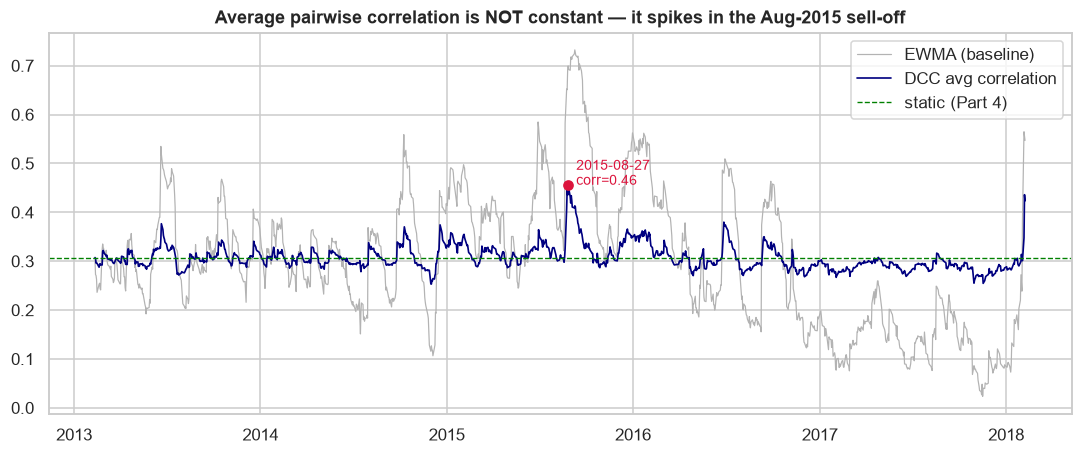

In [4]:
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(out["ewma_avg_corr"].index, out["ewma_avg_corr"].values, color="0.7", lw=.8, label="EWMA (baseline)")
ax.plot(ac.index, ac.values, color="navy", lw=1.1, label="DCC avg correlation")
ax.axhline(out["uncond_avg_corr"], color="green", ls="--", lw=.9, label="static (Part 4)")
peak = ac.idxmax()
ax.annotate(f"  {peak.date()}\n  corr={ac.max():.2f}", (peak, ac.max()), fontsize=9, color="crimson")
ax.scatter([peak], [ac.max()], color="crimson", zorder=5)
ax.set_title("Average pairwise correlation is NOT constant — it spikes in the Aug-2015 sell-off")
ax.legend(); eda.savefig(fig, "p8_dcc_avgcorr.png"); plt.show()

### 6. Correlations rise with fear — the DCC–VIX link

Overlay the average conditional correlation with the VIX. They move together: when fear (implied
vol) rises, so does co-movement. This is the *correlation* face of risk — and why tail events hit
portfolios harder than a static covariance predicts.

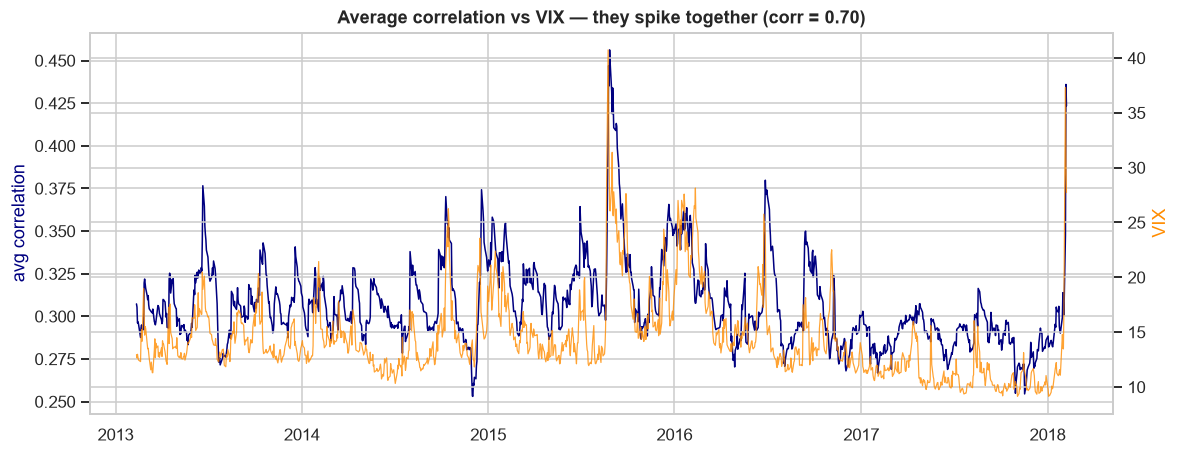

corr(avg DCC correlation, VIX) = 0.70 -> correlations climb with market fear


In [5]:
both = pd.concat([ac.rename("corr"), vix.rename("vix")], axis=1).dropna()
r = both["corr"].corr(both["vix"])
fig, ax1 = plt.subplots(figsize=(12, 4.5))
ax1.plot(both.index, both["corr"], color="navy", lw=1, label="DCC avg corr"); ax1.set_ylabel("avg correlation", color="navy")
ax2 = ax1.twinx(); ax2.plot(both.index, both["vix"], color="darkorange", lw=.8, alpha=.8); ax2.set_ylabel("VIX", color="darkorange")
ax1.set_title(f"Average correlation vs VIX — they spike together (corr = {r:.2f})")
eda.savefig(fig, "p8_corr_vs_vix.png"); plt.show()
print("corr(avg DCC correlation, VIX) = %.2f -> correlations climb with market fear" % r)

### 7. Even individual pairs breathe

The dynamics aren't just an aggregate effect — each pair's conditional correlation wanders over a
wide band. A hedge calibrated on a calm-period correlation can be badly wrong in a stressed one.

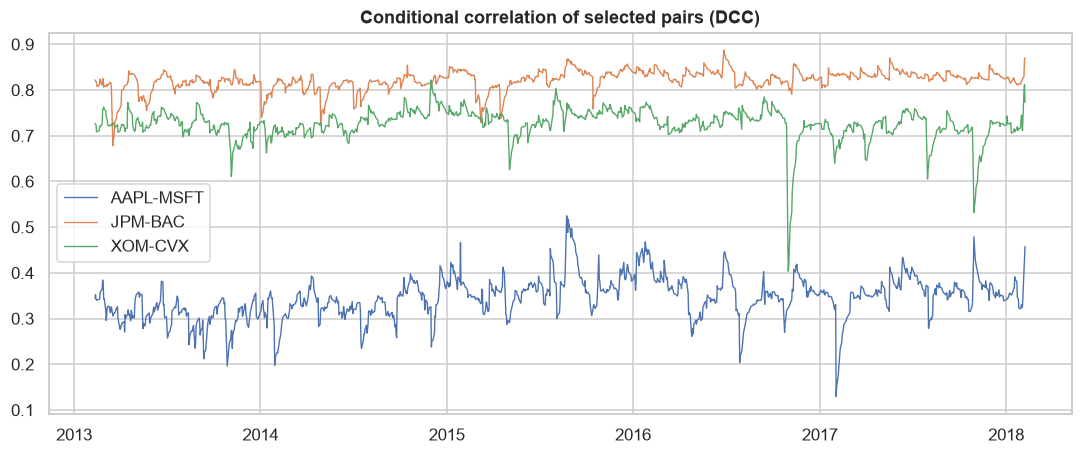

      AAPL-MSFT  JPM-BAC  XOM-CVX
min        0.13     0.68     0.40
mean       0.34     0.82     0.73
max        0.52     0.89     0.82


In [6]:
pc = out["pair_corr"]
fig, ax = plt.subplots(figsize=(12, 4.5))
for c in pc.columns: ax.plot(pc.index, pc[c], lw=.9, label=c)
ax.set_title("Conditional correlation of selected pairs (DCC)"); ax.legend()
eda.savefig(fig, "p8_pair_corr.png"); plt.show()
print(pc.agg(["min","mean","max"]).round(2).to_string())

### 8. Why it matters — diversification erodes exactly when you need it

For an equal-weight book of `N` assets with average correlation `ρ`, portfolio variance scales like
`1/N + (1 − 1/N)·ρ` of the average single-name variance. As `ρ` climbs, that floor rises — the
diversification benefit shrinks. Using the DCC correlation, watch the equal-weight portfolio's vol
(as a fraction of the average single-stock vol) **rise in every stress episode**:

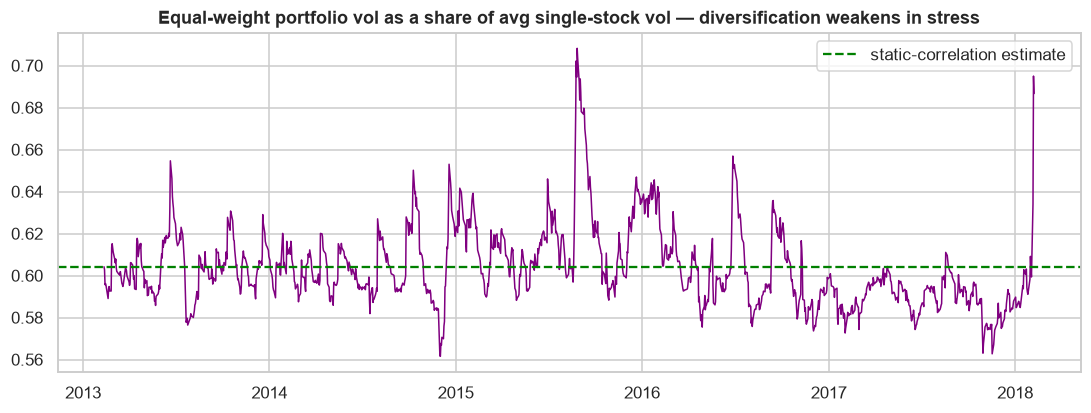

portfolio keeps 56% of single-name vol in calm, but 71% at the correlation peak


In [7]:
N = z.shape[1]
ratio = np.sqrt(1/N + (1 - 1/N) * ac.clip(lower=0))   # port vol / avg single-name vol
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(ratio.index, ratio.values, color="purple", lw=1)
ax.axhline(np.sqrt(1/N + (1-1/N)*out["uncond_avg_corr"]), color="green", ls="--", label="static-correlation estimate")
ax.set_title("Equal-weight portfolio vol as a share of avg single-stock vol — diversification weakens in stress")
ax.legend(); eda.savefig(fig, "p8_diversification.png"); plt.show()
print("portfolio keeps %.0f%% of single-name vol in calm, but %.0f%% at the correlation peak"
      % (100*ratio.min(), 100*ratio.max()))

### Takeaways

- A **static** correlation matrix (Part 4) hides the most important risk fact: correlations are
  **dynamic** and **spike in crises**.
- **DCC-GARCH** models the conditional correlation `R_t` with two extra parameters on top of
  per-asset GARCH; here persistence `a+b ≈ 0.88` (mean-reverting).
- Average correlation swung from **~0.25 (calm) to ~0.46** on the **Aug-2015** sell-off, and tracks
  the **VIX (corr ≈ 0.70)** — co-movement rises with fear.
- Consequently **diversification erodes exactly when you need it**: equal-weight portfolio vol
  climbs toward single-name vol as correlations converge.
- This unifies the course: Part 4's correlation × Part 7's GARCH = a **time-varying covariance
  matrix**, the object real portfolio risk management is built on.

**Where to go next:** realised/high-frequency covariance, a deep-learning forecaster
(`neuralforecast`), or a fresh dataset in a new sibling folder under `practice-eda/`.